# I/O

> input/output management

In [ ]:
#| default_exp io

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
import time
import re

# =================================
# Scientific / data
# =================================
import h5py
import numpy as np

# =================================
# Bioimage IO
# =================================
from bioio import BioImage as AICSImage
from bioio import Writer as writer
from bioio_tifffile import Reader as TiffReader
from bioio_ome_tiff import Reader as OmeTiffReader

# =================================
# Medical imaging
# =================================
from torchio import ScalarImage

# =================================
# fastai
# =================================
from fastai.data.all import *
from fastai.vision.all import *

# =================================
# MONAI
# =================================
from monai.transforms import LoadImage, LoadImaged, SaveImage, SaveImaged
from monai.data.image_reader import ImageReader
from collections.abc import Callable, Iterable, Sequence
from monai.config import PathLike
from monai.data import MetaTensor
from monai.data.utils import is_supported_format
from monai.utils import MetaKeys

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *

---

### ScalarImage

>      ScalarImage (*args, **kwargs)

Image whose pixel values represent scalars.

See :class:`~torchio.Image` for more information.

## Image Writers

In [ ]:
#| export

def write_image(data, file_path, dimension_order="TCZYX"):
    """
    Writes an image to a file.

    :param data: Image data (numpy array, tensor, or AICSImage)
    :param file_path: Path to save the image
    :param format: Format to save the image in (default is png)
    """
    if isinstance(data, torchTensor):
        data = data.numpy()
    elif isinstance(data, AICSImage):
        data = data.data

    if not isinstance(data, np.ndarray):
        raise ValueError("Unsupported data type. Expected numpy array, tensor, or AICSImage.")

    try:
        # file_path = file_path + '.' + format
        writer.save(data, file_path, dimension_order)
        print(f"Image successfully saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while saving the image: {e}")


In [ ]:

# Example usage:
numpy_array = np.random.rand(3, 100, 100)
write_image(numpy_array, './data_examples/output_from_numpy.tiff')

metatensor = torch.rand(3, 100, 100)
write_image(metatensor, './data_examples/output_from_tensor.tiff')

aics_image = AICSImage('./data_examples/example_tiff.tiff')
write_image(aics_image, './data_examples/output_from_tiff.png')

Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0


Image successfully saved to ./data_examples/output_from_numpy.tiff
Image successfully saved to ./data_examples/output_from_tensor.tiff
Image successfully saved to ./data_examples/output_from_tiff.png


In [ ]:
show_doc(SaveImage)

---

### SaveImage

```python

def SaveImage(
    output_dir:PathLike='./', output_postfix:str='trans', output_ext:str='.nii.gz',
    output_dtype:DtypeLike | None=float32, resample:bool=False, mode:str='nearest', padding_mode:str=border,
    scale:int | None=None, dtype:DtypeLike=float64, squeeze_end_dims:bool=True, data_root_dir:PathLike='',
    separate_folder:bool=True, print_log:bool=True, output_format:str='',
    writer:type[image_writer.ImageWriter] | str | None=None, channel_dim:int | None=0,
    output_name_formatter:Callable[[dict, Transform], dict] | None=None, folder_layout:FolderLayoutBase | None=None,
    savepath_in_metadict:bool=False
)->None:


```

*Save the image (in the form of torch tensor or numpy ndarray) and metadata dictionary into files.*

The name of saved file will be `{input_image_name}_{output_postfix}{output_ext}`,
where the `input_image_name` is extracted from the provided metadata dictionary.
If no metadata provided, a running index starting from 0 will be used as the filename prefix.

Args:
    output_dir: output image directory.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_postfix: a string appended to all output file names, default to `trans`.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_ext: output file extension name.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_dtype: data type (if not None) for saving data. Defaults to ``np.float32``.
    resample: whether to resample image (if needed) before saving the data array,
        based on the ``"spatial_shape"`` (and ``"original_affine"``) from metadata.
    mode: This option is used when ``resample=True``. Defaults to ``"nearest"``.
        Depending on the writers, the possible options are

        - {``"bilinear"``, ``"nearest"``, ``"bicubic"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
        - {``"nearest"``, ``"linear"``, ``"bilinear"``, ``"bicubic"``, ``"trilinear"``, ``"area"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#interpolate

    padding_mode: This option is used when ``resample = True``. Defaults to ``"border"``.
        Possible options are {``"zeros"``, ``"border"``, ``"reflection"``}
        See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
    scale: {``255``, ``65535``} postprocess data by clipping to [0, 1] and scaling
        [0, 255] (``uint8``) or [0, 65535] (``uint16``). Default is ``None`` (no scaling).
    dtype: data type during resampling computation. Defaults to ``np.float64`` for best precision.
        if ``None``, use the data type of input data. To set the output data type, use ``output_dtype``.
    squeeze_end_dims: if ``True``, any trailing singleton dimensions will be removed (after the channel
        has been moved to the end). So if input is (C,H,W,D), this will be altered to (H,W,D,C), and
        then if C==1, it will be saved as (H,W,D). If D is also 1, it will be saved as (H,W). If ``False``,
        image will always be saved as (H,W,D,C).
    data_root_dir: if not empty, it specifies the beginning parts of the input file's
        absolute path. It's used to compute ``input_file_rel_path``, the relative path to the file from
        ``data_root_dir`` to preserve folder structure when saving in case there are files in different
        folders with the same file names. For example, with the following inputs:

        - input_file_name: ``/foo/bar/test1/image.nii``
        - output_postfix: ``seg``
        - output_ext: ``.nii.gz``
        - output_dir: ``/output``
        - data_root_dir: ``/foo/bar``

        The output will be: ``/output/test1/image/image_seg.nii.gz``

        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    separate_folder: whether to save every file in a separate folder. For example: for the input filename
        ``image.nii``, postfix ``seg`` and ``folder_path`` ``output``, if ``separate_folder=True``, it will be
        saved as: ``output/image/image_seg.nii``, if ``False``, saving as ``output/image_seg.nii``.
        Default to ``True``.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    print_log: whether to print logs when saving. Default to ``True``.
    output_format: an optional string of filename extension to specify the output image writer.
        see also: ``monai.data.image_writer.SUPPORTED_WRITERS``.
    writer: a customised ``monai.data.ImageWriter`` subclass to save data arrays.
        if ``None``, use the default writer from ``monai.data.image_writer`` according to ``output_ext``.
        if it's a string, it's treated as a class name or dotted path (such as ``"monai.data.ITKWriter"``);
        the supported built-in writer classes are ``"NibabelWriter"``, ``"ITKWriter"``, ``"PILWriter"``.
    channel_dim: the index of the channel dimension. Default to ``0``.
        ``None`` to indicate no channel dimension.
    output_name_formatter: a callable function (returning a kwargs dict) to format the output file name.
        If using a custom ``monai.data.FolderLayoutBase`` class in ``folder_layout``, consider providing
        your own formatter.
        see also: :py:func:`monai.data.folder_layout.default_name_formatter`.
    folder_layout: A customized ``monai.data.FolderLayoutBase`` subclass to define file naming schemes.
        if ``None``, uses the default ``FolderLayout``.
    savepath_in_metadict: if ``True``, adds a key ``"saved_to"`` to the metadata, which contains the path
        to where the input image has been saved.

In [ ]:
#| export
SaveImage = SaveImage
SaveImaged = SaveImaged

## Image Loaders

It uses helper functions to load and preprocess biological images.

### Utils

In [ ]:
#| export
def tiff2torch(file_path: str):
    '''
    Load tiff into pytorch tensor
    '''
    import tifffile as tiff
    
    img = np.array(tiff.imread(file_path))
    return torch_from_numpy(img)

In [ ]:
#| export
def string2dict(s: str) -> dict[str, int | slice | None]:
    """
    Parse layout strings with:
        - sizes: C2
        - slices: Y[100:200]
        - steps:  Y[100:200:2]

    Returns:
        dict[str, int | slice | None]
    """

    result = {}

    pattern = re.findall(
        r"([A-Za-z])"               # axis
        r"(\d+)?"                   # optional size
        r"(?:\[(\d*):(\d*):?(\d*)\])?",  # optional slice w/ step
        s
    )

    for axis, size, start, stop, step in pattern:
        axis = axis.upper()

        # -------------------------
        # slice case
        # -------------------------
        if start or stop or step:
            slc = slice(
                int(start) if start else None,
                int(stop) if stop else None,
                int(step) if step else None,
            )
            result[axis] = slc

        # -------------------------
        # size case
        # -------------------------
        elif size:
            result[axis] = int(size)

        # -------------------------
        # empty axis
        # -------------------------
        else:
            result[axis] = None

    return result

In [ ]:
#| export
def split_path(file_path, # The path to the file to split
                   exts:(L, list)=['.ome.tiff', '.tiff', '.tif', '.png'] # List of filename extensions 
                   ):
    img_ext = [ext for ext in exts if ext in file_path]
    if img_ext == []:
        return file_path, dict()
    p = file_path.split(img_ext[0])
    if len(p) == 1 or p[1] == '':
        return file_path, dict()
    else:
        path = p[0] + img_ext[0]
        ind_dict = string2dict(p[1])
    return path, ind_dict

In [ ]:
split_path('./data_examples/example_ome_tiff.ome.tiff/X[10:20:2]Z0')

('./data_examples/example_ome_tiff.ome.tiff', {'X': slice(10, 20, 2), 'Z': 0})

In [ ]:
#| export
def is_ome_tiff(path: Path) -> bool:
    return path.suffixes[-2:] == [".ome", ".tiff"]

In [ ]:
test_eq(is_ome_tiff(Path('./data_examples/example_ome_tiff.ome.tiff')), True)
test_eq(is_ome_tiff(Path('./data_examples/example_ome.tiff')), False)

In [ ]:
#| export

def extract_formats(filenames: Sequence[str] | str) -> list[str | None]:
    """
    Extract file format(s) from one or multiple filenames.

    Supports:
        - standard extensions (.nii.gz, .png, .npz)
        - HDF5 internal paths (.hdf5/... or .h5/...)

    Args:
        filenames: single path or sequence of paths.

    Returns:
        List of format strings in uppercase (without dots),
        or None if no suffix is found.
    """

    if isinstance(filenames, (str, Path)):
        filenames = [filenames]

    formats = []

    for name in filenames:
        path_str = str(name).lower()

        # HDF5 special case
        if any(ext in path_str for ext in (".h5", ".hdf5")):
            formats.append("HDF5")
            continue

        # Standard suffixes
        suffixes = Path(name).suffixes
        if suffixes:
            fmt = "".join(suffixes).lstrip(".").upper()
            formats.append(fmt)
        else:
            formats.append(None)

    return formats

### BioIO Formats

In [ ]:
#| export
class bioio_loader():
    
    def __init__(self,
                 ind_dict=None, # Dictionary indicating the channels to load
                 loader=None, # Optional custom reader to use for loading the image
                 channels="CZYX" # The desired channel order for the output data
                ):
        store_attr()

    def __call__(self, path) -> Any:
        return self.image_reader(path)
    
    def image_reader(self, 
               path, # The file path to the image             
               ):

        """
        Loads an image from the specified path using AICSImage library.

        Parameters:
            path (str): The file path to the image.

        Returns:
            tuple: A tuple containing the image data and its affine transformation matrix.
                The image data is a NumPy array representing the image.
                The affine transformation matrix is a 4x4 NumPy array.
        """

        ind_dict = self.ind_dict
        if ind_dict == None:
            # parse path string
            path, ind_dict = split_path(str(path))
            
        # Support for tiff files    
        path = str(path)
        image_aics = AICSImage(path, reconstruct_mosaic=False, reader=self.loader)

        # Convert to numpy array    
        data = image_aics.get_image_data(self.channels, **ind_dict)
        # extract metadata
        meta = image_aics.metadata
        # Create an identity affine transformation matrix
        affine = np.eye(4)
        # Return the image data and the affine matrix
        return data, meta, affine


In [ ]:
file_path = 'data_examples/cameraman_noisy.jpg'
test_img, meta, affine = bioio_loader({'Y': slice(0,10)}, channels="CZYX")(file_path)
test_eq(test_img.shape, (1, 1, 10, 225))

In [ ]:
a = MetaTensor(x=test_img, affine=affine, meta=meta)

In [ ]:
test_eq(a.affine, Tensor(np.eye(4)))

In [ ]:
a.detach().cpu().numpy()

array([[[[161, 140, 154, ..., 110, 159, 148],
         [132, 153, 160, ..., 101, 147, 158],
         [166, 148, 171, ..., 152, 141, 151],
         ...,
         [133, 133, 154, ..., 143, 154, 133],
         [163, 154, 146, ..., 152, 135, 166],
         [163, 176, 177, ..., 167, 151, 143]]]],
      shape=(1, 1, 10, 225), dtype=uint8)

In [ ]:
a.meta

{'jfif': 257,
 'jfif_version': (1, 1),
 'jfif_unit': 0,
 'jfif_density': (1, 1),
 'mode': 'RGB',
 'shape': (225, 225),
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS}

### Hierarchical Data Format

In [ ]:
#| export
def split_hdf_path(file_path, # The path to the HDF5 file to split
                   hdf5_exts:(L, list)=['.h5','.hdf5'] # List of filename extensions 
                   ):
    hdf5_ext = [ext for ext in hdf5_exts if ext in file_path][0]
    if hdf5_ext == []:
        return file_path, None, None
    p = file_path.split(hdf5_ext)
    if len(p) == 1 or p[1] == '':
        return file_path, None, None
    else:
        path = p[0] + hdf5_ext
        tmp = p[1].split('/')[1:]
        dataset = os.path.join(*tmp[:-1])
        patch = tmp[-1]
    return path, dataset, patch

In [ ]:
#| export
class hdf5_loader():
    def __init__(self,
                 dataset: Optional[str]=None, # The dataset to load
                 patch: Optional[str]=None, # The patch to load from the dataset
                 hdf5_exts: List[str]=['.h5','.hdf5'], # List of filename extensions 
                 channels: str="CYX" # The desired channel layout for the output data
                ):
        store_attr()

    def __call__(self, path) -> Any:
        return self.image_reader(path)
    
    def image_reader(self, 
               path, # The path to the HDF5 file to be read
               ):
        """
        Reads a *.h5 (HDF5 format) file and returns the image data along with an identity affine matrix.

        Parameters:
        path (str): The path to the file to be read.

        Returns:
        tuple: A tuple containing:
            - data (numpy.ndarray): The image data read from the file.
            - affine (numpy.ndarray): A 4x4 identity affine matrix.
        """
        
        # split path
        if self.dataset == None:
            path, dataset, patch = split_hdf_path(path, self.hdf5_exts)
            self.dataset = dataset
            self.patch = patch

        with h5py.File(path, 'r') as file:
                if self.dataset == None: print('List of datasets in this file: \n',list(file.keys())); return None
                else:
                    data = file[self.dataset + '/' + self.patch][:] 
                    meta = dict(file[self.dataset].attrs)
                    meta['patch_location'] = file[self.dataset + '/' + self.patch].attrs['patch_location']

        # adjust data dimensions according to channels layout
        while len(data.shape) < len(self.channels):
            # add absent dimensions assuming missing dimensions are at the beginning
            data = np.expand_dims(data, axis=0)
        if len(data.shape) > len(self.channels):
            # remove absent dimensions assuming that data is in CZYX order and missing dimensions are at the beginning
            data = data[(0,)*(data.ndim - len(self.channels)) + (slice(None),)*len(self.channels)]
                
        # If affine is not in meta dict, create a 4x4 identity affine NumpyArray
        if 'affine' in meta:
            affine = meta['affine']
        else:
            affine = np.eye(4)

        # Return the image data and the affine matrix
        return data, meta, affine


Images can be loaded by explicitly writing dataset name and path number...

In [ ]:
from bioMONAI.visualize import show_image


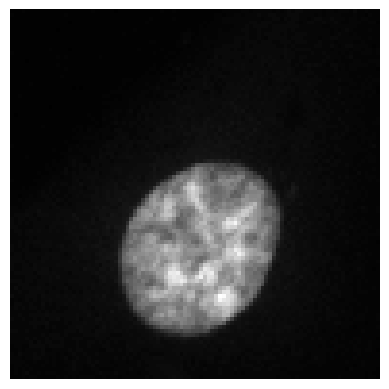

In [ ]:
file_path = './data_examples/0450_1.hdf5'
dataset_name='clean'
patch_num=10

im , meta, _ = hdf5_loader(dataset=dataset_name, patch=patch_num)(file_path)
show_image(im[0])

In [ ]:
im.shape

(1, 96, 96)

... or enconding them in the path, where datasets are subfolders and patches the image files. The latter being compatible with `image_reader` syntaxis.

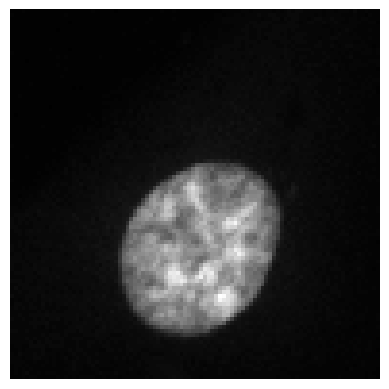

In [ ]:
f = file_path + '/' + dataset_name + '/' + '%d'%(patch_num)
im , meta, _ = hdf5_loader()(f)
show_image(im[0])

### Preprocessing

Define classes to store Metadata

In [ ]:
#| export

def _preprocess(obj: MetaTensor, transforms: Callable|Iterable[Callable]|None=None) -> MetaTensor:
    """
    Apply a sequence of transforms to an image object.

    Args:
        obj: Input image object.
        transforms: Callable or list of callables.

    Returns:
        MetaTensor: Transformed object.
    """
    if transforms is None:
        transforms = []
    elif callable(transforms):
        transforms = [transforms]

    obj.meta['size_original'] = obj.shape
    obj.meta['transforms'] = {}

    for t in transforms:
        start = time.time()

        obj = t(obj)

        obj.meta['transforms'][t.__class__.__name__] = obj.meta['transforms'].get(t.__class__.__name__, [])
        obj.meta['transforms'][t.__class__.__name__] = {
                'time': time.time() - start,
                'params': getattr(t, "__dict__", {}),
        }

    obj.meta['size_after_tfms'] = obj.shape if hasattr(obj, "shape") else None

    return obj

In [ ]:
a.meta

{'jfif': 257,
 'jfif_version': (1, 1),
 'jfif_unit': 0,
 'jfif_density': (1, 1),
 'mode': 'RGB',
 'shape': (225, 225),
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS}

In [ ]:
from monai.transforms import ScaleIntensity

In [ ]:
_preprocess(a, [ScaleIntensity()]).meta

{'jfif': 257,
 'jfif_version': (1, 1),
 'jfif_unit': 0,
 'jfif_density': (1, 1),
 'mode': 'RGB',
 'shape': (225, 225),
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'size_original': torch.Size([1, 1, 10, 225]),
 'transforms': {'ScaleIntensity': {'time': 0.0027577877044677734,
   'params': {'minv': 0.0,
    'maxv': 1.0,
    'factor': None,
    'channel_wise': False,
    'dtype': numpy.float32}}},
 'size_after_tfms': torch.Size([1, 1, 10, 225])}

In [ ]:
test_eq(_preprocess(a, None).meta['size_original'], [1, 1, 10, 225])

### Loaders registry

In [ ]:
#| export

class LoaderRegistry:
    def __init__(self):
        self._loaders = {}

    def register(self, *suffixes):
        def decorator(fn):
            for s in suffixes:
                self._loaders[s.lower()] = fn
            return fn
        return decorator

    def get(self, path: Path):
        full_suffix = "".join(path.suffixes).lower()
        if full_suffix in self._loaders:
            return self._loaders[full_suffix]
        return self._loaders.get(path.suffix.lower())


LOADER_REGISTRY = LoaderRegistry()

Default loader (AICS only)

In [ ]:
#| export
def _load_default(path, ind_dict=None, loader=None, channels="CZYX", **kwargs):
    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    data, meta, affine = bioio_loader(ind_dict, loader=loader, channels=channels)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)



In [ ]:
file_path = 'data_examples/cameraman_noisy.jpg'
_load_default(file_path, {'Y': slice(0,10)}, channels="CZYX")
test_eq(test_img.shape, (1, 1, 10, 225))

### Registered loaders

In [ ]:
#| export
@LOADER_REGISTRY.register(".npy")
def _load_npy(path, **kwargs):
    data = np.load(path)
    return MetaTensor(x=data) 


In [ ]:
#| export
@LOADER_REGISTRY.register(".npz")
def _load_npz(path, npz_key=None, **kwargs):
    npz_file = np.load(path)

    key = npz_key or next(iter(npz_file.keys()))
    if key not in npz_file:
        raise KeyError(f"Key '{key}' not found. Available: {list(npz_file.keys())}")

    return MetaTensor(x=npz_file[key])



In [ ]:
#| export
@LOADER_REGISTRY.register(".h5", ".hdf5")
def _load_hdf5(path, channels="CZYX", **kwargs):
    path_str = str(path)

    hdf5_ext = [ext for ext in ('.h5', '.hdf5') if ext in path_str]
    path, dataset, patch = split_hdf_path(path_str, hdf5_exts=hdf5_ext)

    data, meta, affine = hdf5_loader(dataset=dataset, patch=patch, hdf5_exts=hdf5_ext, channels=channels)(path)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| export
@LOADER_REGISTRY.register(".png")
def _load_png(path, ind_dict=None, channels="CZYX", loader=None, **kwargs):
    """
    Load a PNG image using AICSImage.

    Returns:
        ScalarImage containing the image tensor.
    """

    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    channels = channels.replace("C", "S")
    data, meta, affine = bioio_loader(ind_dict, loader=loader, channels=channels)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| export
@LOADER_REGISTRY.register(".tiff", ".tif")
def _load_tiff(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load a TIFF image using AICSImage.

    Returns:
        ScalarImage containing the image tensor.
    """

    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    
    # ome.tiff require a separate loader than regular tiff
    if is_ome_tiff(Path(path_str)):
       image_loader = OmeTiffReader
    else:
        image_loader = TiffReader

    data, meta, affine = bioio_loader(ind_dict, loader=image_loader, channels=channels)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)

### Loader resolution


In [ ]:
#| export
def _get_loader(path: Path):
    """
    Select appropriate loader based on file format.

    Priority:
        1. registry-based loader (exact match)
        2. format-based fallback (via extract_formats)
        3. default loader
    """

    # 1. Registry-based detection (fast path)
    loader = LOADER_REGISTRY.get(path)
    if loader:
        return loader

    # 2. Format-based detection (HDF5-aware)
    fmt = extract_formats(path)[0]

    if fmt == "HDF5":
        return _load_hdf5

    # 3. Default fallback
    return _load_default

### Load and preprocess

In [ ]:
#| export

def _load_and_preprocess(
    file_path: PathLike,
    transforms: Callable|Iterable[Callable]|None =None,
    loader: Callable|None =None,
    channels: str ="CZYX",
    ind_dict: dict|None =None,
    npz_key: str|None =None,
) -> MetaTensor:
    """
    Load image and apply preprocessing transforms.

    Also attaches file format metadata.
    """
    path = Path(file_path)

    image_loader = _get_loader(path)
    metatensor = image_loader(path, loader=loader, channels=channels, ind_dict=ind_dict, npz_key=npz_key)

    metatensor = _preprocess(metatensor, transforms)

    # format extraction
    metatensor.meta['format'] = extract_formats(path)[0]
    # save channels info
    metatensor.meta['layout'] = channels

    return metatensor

In [ ]:
_load_and_preprocess('./data_examples/example_tiff.tiff', channels="YX").shape

torch.Size([512, 512])

In [ ]:
_load_and_preprocess('./data_examples/example_tiff.tiff', ind_dict={'X': slice(0, 10)}).shape

torch.Size([1, 96, 512, 10])

In [ ]:
metatensor= _load_and_preprocess(f, channels="CYX")

test_eq(metatensor.data.shape, im.shape)
test_eq(metatensor.meta['size_after_tfms'], im.shape)

In [ ]:
metatensor.meta

{affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'size_original': torch.Size([1, 96, 96]),
 'transforms': {},
 'size_after_tfms': torch.Size([1, 96, 96]),
 'format': 'HDF5',
 'layout': 'CYX'}

### Read multichannel data

Lazy Streaming

In [ ]:
#| export

def _multi_sequence_stream(
    image_paths: Sequence[PathLike],
    transforms=None,
    loader=None,
    channels="CZYX",
    ind_dict=None,
    npz_key=None,
) -> Iterable[MetaTensor]:
    """
    Lazily yield preprocessed image samples.

    Args:
        image_paths: Iterable of file paths.
        transforms: Optional transforms.
        reader: Optional reader.
        npz_key: Optional NPZ key.

    Yields:
        tuple (image, metadata)
    """
    for p in image_paths:
        yield _load_and_preprocess(
            p,
            transforms=transforms,
            loader=loader,
            channels=channels,
            ind_dict=ind_dict,
            npz_key=npz_key,
        )

## Image Readers

### Utils

In [ ]:
#| export
def _stack(
    input_metatensors: Sequence[MetaTensor],
    stack_axis: str = "C",
    channels: str = "CZYX",
    dtype: torch.dtype = torch.float32,
    squeeze: bool = True,
) -> torch.Tensor:
    """
    Stack a sequence of MetaTensors into a single tensor.
    
    Args:
        input_metatensors: Sequence of MetaTensors to stack.
        stack_axis: Axis along which to stack (e.g., "S" for sequence).
        channels: Desired channel order for output (e.g., "CZYX").
        dtype: Data type for output tensor.
        squeeze: Whether to squeeze singleton dimensions before stacking.
    
    Returns:
        Stacked tensor with metadata from each input tensor indexed by position.
    
    Raises:
        ValueError: If input is empty or invalid parameters provided.
    """
    # Validation
    if not input_metatensors:
        raise ValueError("input_metatensors cannot be empty")
    if not stack_axis or len(stack_axis) != 1:
        raise ValueError(f"stack_axis must be a single character, got {stack_axis!r}")
    if not channels or not all(c in "SCZYX" for c in channels):
        raise ValueError(f"channels must contain valid axis labels, got {channels!r}")
    
    # Preprocess tensors: squeeze and convert dtype
    processed = [
        t.squeeze().to(dtype) if squeeze else t.to(dtype)
        for t in input_metatensors
    ]
    
    # Preserve metadata from each original tensor
    metadata_dict = {i: m.meta for i, m in enumerate(input_metatensors)}
    
    # Case A: stack_axis is new (not in current channels)
    if stack_axis not in channels:
        # Stack along new dimension at position 0
        stacked = torch.stack(processed, dim=0)
        # Update metadata: new axis prepended to layout, plus indexed original metadata
        stacked.meta.update({
            'layout': stack_axis + channels,
            'tensors': metadata_dict
        })
        return stacked
    
    # Case B: stack_axis exists in channels → concatenate along that axis
    axis_idx = channels.index(stack_axis)
    
    # Stack first to add a new dimension, then move it to the target position
    stacked = torch.stack(processed, dim=0)
    
    # Move the stacking dimension to the target axis position
    # (adjust for the fact that we stacked at dim=0)
    target_dim = axis_idx + 1  # +1 because stack added a dimension at position 0
    stacked = torch.moveaxis(stacked, 0, target_dim)
    
    # Flatten the stacking dimension into the target axis
    shape = list(stacked.shape)
    shape[axis_idx:axis_idx+2] = [shape[axis_idx] * shape[axis_idx+1]]
    output = stacked.reshape(shape)
    
    # Update metadata with indexed original metadata
    output.meta.update({
        'layout': channels,
        'tensors': metadata_dict
    })
    
    return output


def _meta_from_layout(shape: tuple[int, ...],           # The shape of the image tensor
                      layout: str                       # The channel layout string (e.g., "CZYX")
                      ) -> dict[str, int | str | None]: # A dictionary containing metadata extracted from the layout, including size, width, height, channels, depth, frames, sequence, mode, and kind.
    """
    Extract metadata from channel layout.
    Args:
        shape: The shape of the image tensor
        layout: The channel layout string (e.g., "CZYX")    
    Returns:
        A dictionary containing metadata extracted from the layout, including size, width, height, channels, depth, frames, sequence, mode, and kind.
     """

    _channel_modes = {1: "L", 3: "RGB"}
    
    if len(shape) != len(layout):
        raise ValueError(f"{shape} vs {layout}")

    axis_map = dict(zip(layout, shape))

    meta = {
        "size_output": tuple(shape),
        "width": axis_map.get("X"),
        "height": axis_map.get("Y"),
        "channels": axis_map.get("C"),
        "depth": axis_map.get("Z"),
        "frames": axis_map.get("T"),
        "sequence": axis_map.get("S"),
        MetaKeys.SPATIAL_SHAPE: tuple(axis_map[ax] for ax in "ZYX" if ax in axis_map),
    }

    # mode
    c = meta["channels"]
    meta["mode"] = (
        "L" if c is None else _channel_modes.get(c, f"multichannel ({c})")
    )

    # kind
    if meta["sequence"] is not None and meta["sequence"] > 1:
        meta["kind"] = "sequence"
    if meta["frames"] is not None and meta["frames"] > 1:
        meta["kind"] = "video"
    elif meta["depth"] is not None and meta["depth"] > 1:
        meta["kind"] = "volume"
    else:
        meta["kind"] = "image"

    if "C" in layout:
        meta[MetaKeys.ORIGINAL_CHANNEL_DIM] = layout.index("C")
    else:
        meta[MetaKeys.ORIGINAL_CHANNEL_DIM] = float("nan")

    return meta



### Base image reader

In [ ]:
#| export
def image_reader(
    file_path: PathLike | Sequence[PathLike],           # The file path(s) to the image(s) to be read. Can be a single path or a sequence of paths for multi-image loading.
    lazy: bool = False,                                 # Whether to use lazy loading (streaming) for multi-image inputs. If True, returns an iterable of MetaTensors instead of a single stacked tensor.
    output: str = "tensor",                             # The desired output format. Options: "nparray", "nparray+meta", "tensor", "tensor+meta", "metatensor"
    transforms: Callable|list[Callable]|None = None,    # Optional transforms to apply to the loaded image(s). Can be a single callable or a list of callables.
    loader: Callable|None = None,                       # Optional custom reader to use for loading the image. If None, the loader will be selected based on file format.
    channels: str ="CZYX",                              # The desired channel layout for the output tensor. Should be compatible with the input data and the loader used.
    ind_dict: dict|None = None,                         # Optional dictionary indicating specific channels or slices to load. Keys should correspond to axes in the channel layout (e.g., {"Y": slice(0, 10)}).
    npz_key: str|None = None,                           # The key to use for loading data from .npz files.
    dtype=torch.float32,                                # The desired data type for the output tensor. Only applicable if output includes tensor formats.
    squeeze: bool = False,                              # Whether to squeeze singleton dimensions from the input tensors before stacking.
    stack_axis: str = "C",                              # The axis along which to stack multi-image inputs. Should be one of the characters in the channel layout (e.g., "C", "S") or a new axis if not present in the layout.
) -> (                                                  # The type of the returned value depends on the `output` parameter.
    MetaTensor
    | np.ndarray
    | tuple[np.ndarray, dict]
    | torch.Tensor
    | tuple[torch.Tensor, dict]
    | tuple[torch.Tensor, dict]                         
):
    """
    Main entry point for medical image loading.

    ----------------------------------------------------------------------
    OVERVIEW
    ----------------------------------------------------------------------
    Supports:
        - single image loading
        - multi-image / multi-sequence loading
        - lazy or eager execution
        - scalar, NumPy, tensor, and MetaTensor outputs
        - flexible axis control for multi-image stacking

    ----------------------------------------------------------------------
    AXIS MODEL
    ----------------------------------------------------------------------
    Two concepts define tensor layout:

    1. channels:
        Defines per-image axis layout (e.g. "CZYX")

    2. stack_axis:
        Defines how multi-image inputs are injected.

    RULES:

    CASE 1:
        If stack_axis is IN channels:
            → images are stacked along that axis (no new axis created)
            → that axis becomes sequence dimension

    CASE 2:
        If stack_axis is NOT in channels:
            → a new axis is created at stack_axis position
            → sequence dimension is inserted

    ----------------------------------------------------------------------
    OUTPUT MODES
    ----------------------------------------------------------------------
        "nparray"       -> np.ndarray
        "nparray+meta"  -> (np.ndarray, Meta or list[Meta])
        "tensor"        -> torch.Tensor
        "tensor+meta"   -> (torch.Tensor, Meta or list[Meta])
        "metatensor"    -> MetaTensor

    ----------------------------------------------------------------------
    """
    # loader
    def _load(p):
        return _load_and_preprocess(
            p,
            transforms=transforms,
            loader=loader,
            channels=channels,
            ind_dict=ind_dict,
            npz_key=npz_key,
        )

    def _iter_multi():
        if lazy:
            return _multi_sequence_stream(
                file_path,
                transforms=transforms,
                loader=loader,
                channels=channels,
                ind_dict=ind_dict,
                npz_key=npz_key,
            )
        return [_load(p) for p in file_path]

    

    def _to_numpy(tensor):
        return tensor.detach().cpu().numpy()

    # -------------------------------------------------
    # detect multi
    # -------------------------------------------------
    # if isinstance(file_path, Sequence) and not isinstance(file_path, (str, Path)) and len(file_path) == 1:
    #     file_path = file_path

    is_multi = isinstance(file_path, Sequence) and not isinstance(file_path, (str, Path))

    # =====================================================
    # MULTI CASE
    # =====================================================
    if is_multi:
        metatensors = _iter_multi()
        metatensor = _stack(metatensors, stack_axis=stack_axis, channels=channels, dtype=dtype, squeeze=squeeze)
        metatensor.meta.update(_meta_from_layout(metatensor.shape, metatensor.meta['layout']))

        if output == "metatensor":
            return metatensor

        if output == "tensor":
            return Tensor(metatensor)

        if output == "tensor+meta":
            return Tensor(metatensor), {i:m.meta for i, m in enumerate(metatensors)}

        if output == "nparray":
            return _to_numpy(metatensor)
        
        if output == "nparray+meta":
            return _to_numpy(metatensor), {i:m.meta for i, m in enumerate(metatensors)}


        raise ValueError(f"Unknown output mode: {output}")

    # =====================================================
    # SINGLE CASE
    # =====================================================
    metatensor = _load(file_path)
    metatensor.meta.update(_meta_from_layout(metatensor.shape, channels))

    if squeeze:
        metatensor = metatensor.squeeze()

    metatensor = metatensor.to(dtype)

    if output == "metatensor":
        return metatensor
    
    if output == "tensor":
        return Tensor(metatensor)

    if output == "tensor+meta":
        return Tensor(metatensor), metatensor.meta
    
    if output == "nparray":
        return _to_numpy(metatensor)

    if output == "nparray+meta":
        return _to_numpy(metatensor), metatensor.meta

    raise ValueError(f"Unknown output mode: {output}")

In [ ]:
from monai.transforms import SpatialCrop

In [ ]:
# =====================================================
# Transform metadata is correctly recorded
# =====================================================
out = image_reader(f, transforms=[SpatialCrop(roi_center=(0,10,10), roi_size=(1,5,5))], output="tensor+meta")

test_eq(len(out[1]['transforms']) > 0, True)
test_eq(''.join(out[1]['transforms']), "SpatialCrop")


# =====================================================
# MetaTensor output (single)
# =====================================================
t = image_reader(f, output="metatensor")

test_eq(type(t).__name__, "MetaTensor")
test_eq(hasattr(t, "data"), True)
test_eq(hasattr(t, "meta"), True)

# meta must be dict (as per new implementation)
test_eq(isinstance(t.meta, dict), True)

# =====================================================
# NumPy output (single)
# =====================================================
arr = image_reader(f, output="nparray", channels="CYX")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape, im.shape)

# =====================================================
# NumPy + meta (single)
# =====================================================
arr, meta = image_reader(f, output="nparray+meta", channels="CYX")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape, im.shape)
test_eq("size_original" in meta, True)

# =====================================================
# Tensor output (single)
# =====================================================
t = image_reader(f, channels="CYX")

test_eq(t.shape, im.shape)

# =====================================================
# Tensor + meta (single)
# =====================================================
t, meta = image_reader(f, output="tensor+meta", channels="CYX")

test_eq(t.shape, im.shape)
test_eq("size_original" in meta, True)

# =====================================================
# MetaTensor consistency (single)
# =====================================================
t = image_reader(f, output="metatensor", channels="CYX")

test_eq(t.data.shape, im.shape)
test_eq(isinstance(t.meta, dict), True)

# =====================================================
# Multi-sequence NumPy stacking
# =====================================================
arr = image_reader([f, f], output="nparray")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape[0], 2)
test_eq(arr.shape[1:], im.shape)

# =====================================================
# Multi-sequence NumPy + meta
# =====================================================
arr, metas = image_reader([f, f], output="nparray+meta")

test_eq(isinstance(arr, np.ndarray), True)
test_eq(arr.shape[0], 2)
test_eq(len(metas), 2)

# =====================================================
# Multi-sequence tensor stacking
# =====================================================
t = image_reader([f, f], output="tensor")

test_eq(t.shape[0], 2)
test_eq(t.shape[1:], im.shape)

# =====================================================
# Multi-sequence tensor + meta
# =====================================================
t, metas = image_reader([f, f], output="tensor+meta")

test_eq(t.shape[0], 2)
test_eq(len(metas), 2)

# =====================================================
# MetaTensor multi consistency
# =====================================================
t = image_reader([f, f], output="metatensor")

test_eq(type(t).__name__, "MetaTensor")
test_eq(t.data.shape[0], 2)
test_eq(len(t.meta), 19) 

In [ ]:
t.meta

{affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'size_original': torch.Size([1, 1, 96, 96]),
 'transforms': {},
 'size_after_tfms': torch.Size([1, 1, 96, 96]),
 'format': 'HDF5',
 'layout': 'CZYX',
 'tensors': {0: {affine: tensor([[1., 0., 0., 0.],
           [0., 1., 0., 0.],
           [0., 0., 1., 0.],
           [0., 0., 0., 1.]], dtype=torch.float64),
   space: RAS,
   'size_original': torch.Size([1, 1, 96, 96]),
   'transforms': {},
   'size_after_tfms': torch.Size([1, 1, 96, 96]),
   'format': 'HDF5',
   'layout': 'CZYX'},
  1: {affine: tensor([[1., 0., 0., 0.],
           [0., 1., 0., 0.],
           [0., 0., 1., 0.],
           [0., 0., 0., 1.]], dtype=torch.float64),
   space: RAS,
   'size_original': torch.Size([1, 1, 96, 96]),
   'transforms': {},
   'size_after_tfms': torch.Size([1, 1, 96, 96]),
   'format': 'HDF5',
   'layout': 'CZYX'}},
 'size_output': (2, 1, 96, 96),

In [ ]:
t = image_reader([f, f], output="metatensor", channels="ZYX")
test_eq(t.shape, (2, 1, 96, 96))

In [ ]:
d = {"images": ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff']}

In [ ]:
t = image_reader(d["images"], output="metatensor", channels="ZYX")
test_eq(t.shape, (2, 96, 512, 512))

In [ ]:
#| export
LoadImage = LoadImage
LoadImaged = LoadImaged

### Runtime reader

In [ ]:
#| export
class BioImageReader(ImageReader):
    def __init__(
        self,
        converter: Callable[[MetaTensor], MetaTensor] | None = None,  # A callable that takes a MetaTensor and returns a MetaTensor
        reverse_indexing: bool = False,
        **kwargs,
    ):
        super().__init__()
        self.converter = converter
        self.reverse_indexing = reverse_indexing
        self.kwargs = kwargs

    # --------------------------------------------------
    def verify_suffix(self, filename:Sequence[PathLike] | PathLike) -> bool:
        suffixes = self._get_supported_suffixes()
        return is_supported_format(filename, suffixes)


    def _get_supported_suffixes(self) -> list[str]:
        """
        Collect supported suffixes from loader registry.
        """
        suffixes = set()

        for loader in LOADER_REGISTRY.values():
            exts = getattr(loader, "suffixes", None)
            if exts:
                suffixes.update(exts)

        return list(suffixes)

    # --------------------------------------------------
    def read(self, data: PathLike | Sequence[PathLike] | np.ndarray, **kwargs) -> MetaTensor:
        kwargs_ = {**self.kwargs, **kwargs}
        if len(data) == 1 and isinstance(data, Sequence) and not isinstance(data, (str, Path)):
            data = data[0]

        mt = image_reader(
            data,
            output="metatensor",
            **kwargs_,
        )

        if self.converter:
            mt = self.converter(mt)

        return mt

    # --------------------------------------------------
    def get_data(self, img: MetaTensor) -> tuple[np.ndarray, dict]:

        if self.reverse_indexing and img.ndim >= 2:
            img = MetaTensor(
                x=img.swapaxes(-1, -2),
                meta=img.meta,
            )

        # extract numpy array
        array = img.as_tensor().cpu().numpy()

        # ensure plain dict
        meta = dict(img.meta)

        return array, meta 
    
    def _get_spatial_shape(self, img: MetaTensor):
        m = img.meta
        return tuple(
            v for v in (m.get("width"), m.get("height"), m.get("depth")) if v is not None
        )

In [ ]:
t = LoadImage(BioImageReader(), ensure_channel_first=True)('./data_examples/example_tiff.tiff')
# t = BioImageReader(channels="CZYX").read('./data_examples/example_tiff.tiff')
test_eq(t.shape, [1, 96, 512, 512])
t.meta


{256: 512,
 257: 512,
 258: 8,
 259: <COMPRESSION.NONE: 1>,
 262: <PHOTOMETRIC.MINISBLACK: 1>,
 273: (8,),
 274: <ORIENTATION.TOPLEFT: 1>,
 277: 1,
 278: 512,
 279: (262144,),
 284: <PLANARCONFIG.CONTIG: 1>,
 339: <SAMPLEFORMAT.UINT: 1>,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'size_original': (1, 96, 512, 512),
 'transforms': {},
 'size_after_tfms': (1, 96, 512, 512),
 'format': 'TIFF',
 'layout': 'CZYX',
 'size_output': (1, 96, 512, 512),
 'width': 512,
 'height': 512,
 'channels': 1,
 'depth': 96,
 'frames': None,
 'sequence': None,
 spatial_shape: (96, 512, 512),
 'mode': 'L',
 'kind': 'volume',
 original_channel_dim: 0,
 'filename_or_obj': 'data_examples/example_tiff.tiff'}

In [ ]:
data, metadata = BioImageReader().get_data(t)
test_eq(type(data), np.ndarray)
test_eq(metadata, t.meta)

In [ ]:
t = LoadImage(BioImageReader, channels="YX")('./data_examples/example_tiff.tiff')

In [ ]:
t.shape

torch.Size([512, 512])

In [ ]:
t.meta

{256: 512,
 257: 512,
 258: 8,
 259: <COMPRESSION.NONE: 1>,
 262: <PHOTOMETRIC.MINISBLACK: 1>,
 273: (8,),
 274: <ORIENTATION.TOPLEFT: 1>,
 277: 1,
 278: 512,
 279: (262144,),
 284: <PLANARCONFIG.CONTIG: 1>,
 339: <SAMPLEFORMAT.UINT: 1>,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS,
 'size_original': (512, 512),
 'transforms': {},
 'size_after_tfms': (512, 512),
 'format': 'TIFF',
 'layout': 'YX',
 'size_output': (512, 512),
 'width': 512,
 'height': 512,
 'channels': None,
 'depth': None,
 'frames': None,
 'sequence': None,
 spatial_shape: (512, 512),
 'mode': 'L',
 'kind': 'image',
 original_channel_dim: nan,
 'filename_or_obj': 'data_examples/example_tiff.tiff'}

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()